In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/datasets/users_behavior.csv')
df.head()

,calls,minutes,messages,mb_used,is_ultra
0,40.0,311.90,83.0,19915.42,0
1,85.0,516.75,56.0,22696.96,0
2,77.0,467.66,86.0,21060.45,0
3,106.0,745.53,81.0,8437.39,1
4,66.0,418.74,1.0,14502.75,0


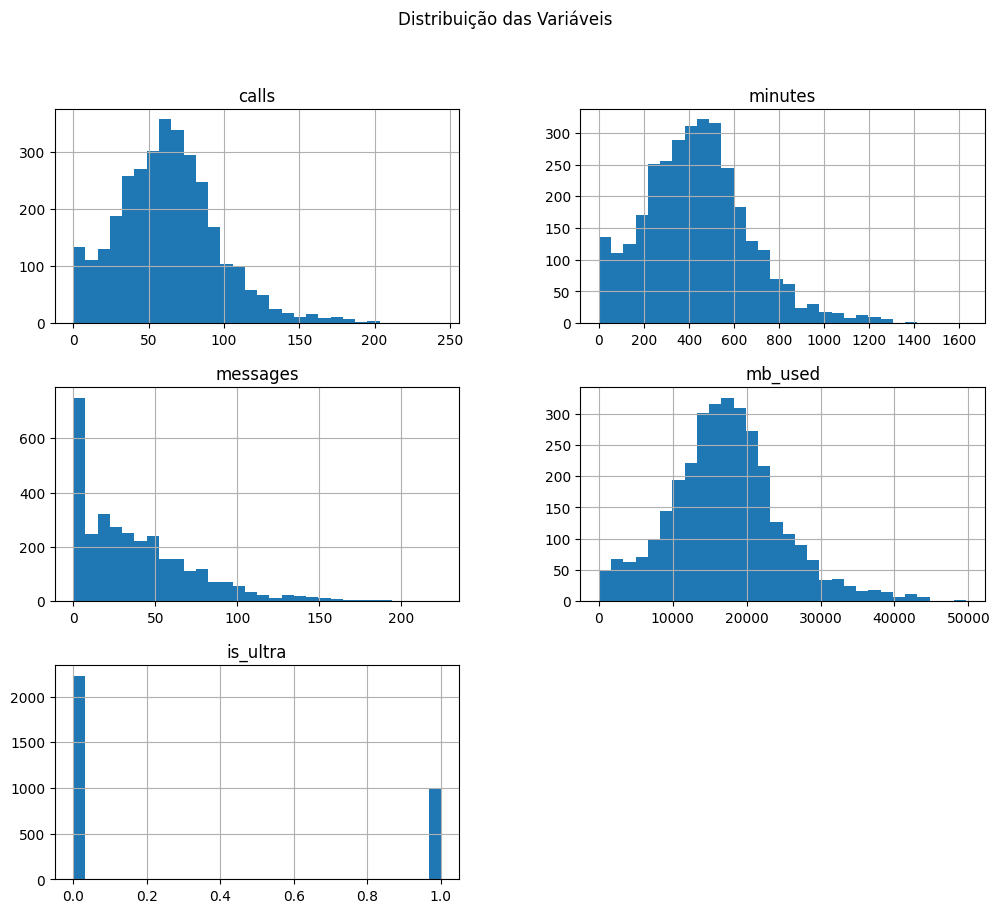

In [9]:
df.hist(figsize=(12, 10), bins=30)
plt.suptitle("Distribuição das Variáveis")
plt.show()

In [3]:
features = df.drop('is_ultra', axis=1)
target = df['is_ultra']
features_train, features_temp, target_train, target_temp = train_test_split(
    features, target, test_size=0.4, random_state=54321
)
features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp, target_temp, test_size=0.5, random_state=54321
)
print(features_train.shape)
print(features_valid.shape)
print(features_test.shape)

(1928, 4)
(643, 4)
(643, 4)


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os conjuntos de dados foram divididos em `treino`, `validação` e `teste`.
- Os conjuntos de dados foram dividos em tamanhos adequados.
</div>

In [4]:
best_model = None
best_accuracy = 0
best_depth = 0

for depth in range(1, 11):
    model = DecisionTreeClassifier(max_depth=depth, random_state=54321)
    model.fit(features_train, target_train)
    predictions = model.predict(features_valid)
    accuracy = accuracy_score(target_valid, predictions)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_depth = depth

print("Melhor depth:", best_depth)

print("Acurácia:", best_accuracy)

Melhor depth: 10
Acurácia: 0.7822706065318819


In [5]:
best_model = None
best_accuracy = 0
best_estimators = 0

for est in range(10, 101, 10):
    model = RandomForestClassifier(n_estimators=est, random_state=54321)
    model.fit(features_train, target_train)
    predictions = model.predict(features_valid)
    accuracy = accuracy_score(target_valid, predictions)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_estimators = est

print("Melhor n_estimators:", best_estimators)

print("Acurácia:", best_accuracy)

Melhor n_estimators: 40
Acurácia: 0.7838258164852255


In [6]:
best_model = None
best_accuracy = 0
best_depth = 0
best_estimators = 0

for depth in range(5, 16):

    for est in range(20, 101, 20):

        model = RandomForestClassifier(
            n_estimators=est,
            max_depth=depth,
            random_state=54321
        )

        model.fit(features_train, target_train)

        predictions = model.predict(features_valid)

        accuracy = accuracy_score(target_valid, predictions)

        if accuracy > best_accuracy:

            best_accuracy = accuracy
            best_model = model
            best_depth = depth
            best_estimators = est

print("Melhor depth:", best_depth)
print("Melhor n_estimators:", best_estimators)
print("Acurácia:", best_accuracy)

Melhor depth: 9
Melhor n_estimators: 80
Acurácia: 0.7978227060653188


In [7]:

# Testei três modelos: regressão logística, árvore de decisão e random forest.

# A árvore de decisão já teve um bom resultado (cerca de 0.78), mas o desempenho variava bastante dependendo da profundidade.

# O random forest foi o melhor modelo, chegando próximo de 0.80 de acurácia após ajustar n_estimators e max_depth. Ele se mostrou mais estável e consistente.

# Já a regressão logística teve um desempenho menor, provavelmente porque os dados não são tão lineares.

# Por isso, escolhi o random forest como modelo final.

In [8]:
# No teste final, o modelo manteve um desempenho parecido com o da validação, o que mostra que ele generaliza bem e não apenas decorou os dados.

# O random forest conseguiu prever corretamente a maioria dos casos, mostrando que é uma boa escolha para esse problema.

# Mesmo não sendo perfeito, o modelo apresenta resultados consistentes e confiáveis.